# 05 – Policy-Specific Sobol Analysis and Feature Scoring

This notebook conducts:
- Sobol sensitivity analysis of deaths across multiple user-defined policies
- Rule induction-based feature scoring per policy

Policies are manually constructed. Sensitivity is analyzed using `SALib`, and feature importance is assessed using `EMA Workbench`.


## 1. Setup: Imports, Logging, and Model Initialization


In [4]:
from ema_workbench import (
    Policy, Model, ema_logging,
    MultiprocessingEvaluator, Samplers
)
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.analysis import feature_scoring
from SALib.analyze.sobol import analyze as sobol_analyze

from dike_model_function import DikeNetwork
from problem_formulation import get_model_for_problem_formulation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

ema_logging.log_to_stderr(ema_logging.INFO)

def setup_dike_model(formulation_index=3):
    model, planning_steps = get_model_for_problem_formulation(formulation_index)
    uncertainties = copy.deepcopy(model.uncertainties)
    problem = get_SALib_problem(uncertainties)
    return model, problem

dike_model, problem = setup_dike_model()


## 2. Define Policies (including do-nothing baseline)
Manually define a list of selected policies for scenario evaluation.


In [5]:
def get_do_nothing_dict():
    return {lever.name: 0 for lever in dike_model.levers}

def build_selected_policies(model):
    do_nothing = get_do_nothing_dict()

    policies = [

    # 🔹 Policy 360
    Policy(
        "policy_360",
        **dict(
            get_do_nothing_dict(),
            **{
                "1_RfR 2": 1, "2_RfR 1": 1, "2_RfR 2": 1, "3_RfR 0": 1, "3_RfR 2": 1,
                "4_RfR 1": 1, "4_RfR 2": 1,
                "A.1_DikeIncrease 0": 3, "A.1_DikeIncrease 1": 3, "A.1_DikeIncrease 2": 10,
                "A.2_DikeIncrease 0": 9, "A.2_DikeIncrease 1": 8, "A.2_DikeIncrease 2": 4,
                "A.3_DikeIncrease 0": 8, "A.3_DikeIncrease 1": 1, "A.3_DikeIncrease 2": 9,
                "A.4_DikeIncrease 1": 6, "A.4_DikeIncrease 2": 7,
                "A.5_DikeIncrease 0": 9, "A.5_DikeIncrease 1": 6, "A.5_DikeIncrease 2": 1,
                "EWS_DaysToThreat": 0
            }
        )
    ),

    # 🔹 Policy 946
    Policy(
        "policy_946",
        **dict(
            get_do_nothing_dict(),
            **{
                "0_RfR 1": 1,
                "1_RfR 0": 1, "1_RfR 1": 1, "1_RfR 2": 1,
                "3_RfR 0": 1, "3_RfR 2": 1,
                "4_RfR 2": 1,
                "A.1_DikeIncrease 0": 1, "A.1_DikeIncrease 2": 10,
                "A.2_DikeIncrease 0": 5, "A.2_DikeIncrease 1": 8, "A.2_DikeIncrease 2": 8,
                "A.3_DikeIncrease 0": 1, "A.3_DikeIncrease 1": 10, "A.3_DikeIncrease 2": 2,
                "A.4_DikeIncrease 1": 8, "A.4_DikeIncrease 2": 3,
                "A.5_DikeIncrease 0": 10, "A.5_DikeIncrease 1": 7, "A.5_DikeIncrease 2": 8,
                "EWS_DaysToThreat": 1
            }
        )
    ),

    # 🔹 Policy 647
    Policy(
        "policy_647",
        **dict(
            get_do_nothing_dict(),
            **{
                "1_RfR 1": 1, "1_RfR 2": 1,
                "2_RfR 0": 1,
                "3_RfR 0": 1, "3_RfR 1": 1, "3_RfR 2": 1,
                "4_RfR 0": 1, "4_RfR 1": 1,
                "A.1_DikeIncrease 0": 3, "A.1_DikeIncrease 1": 4, "A.1_DikeIncrease 2": 6,
                "A.2_DikeIncrease 0": 8, "A.2_DikeIncrease 1": 5, "A.2_DikeIncrease 2": 5,
                "A.3_DikeIncrease 0": 2, "A.3_DikeIncrease 1": 10, "A.3_DikeIncrease 2": 10,
                "A.4_DikeIncrease 0": 4, "A.4_DikeIncrease 1": 6, "A.4_DikeIncrease 2": 8,
                "A.5_DikeIncrease 0": 10, "A.5_DikeIncrease 1": 1, "A.5_DikeIncrease 2": 2,
                "EWS_DaysToThreat": 3
            }
        )
    ),

    # 🔹 Policy 776
    Policy(
        "policy_776",
        **dict(
            get_do_nothing_dict(),
            **{
                "1_RfR 1": 1, "1_RfR 2": 1,
                "2_RfR 1": 1,
                "3_RfR 0": 1, "3_RfR 1": 1, "3_RfR 2": 1,
                "4_RfR 0": 1, "4_RfR 1": 1, "4_RfR 2": 1,
                "A.1_DikeIncrease 1": 9, "A.1_DikeIncrease 2": 9,
                "A.2_DikeIncrease 0": 3, "A.2_DikeIncrease 1": 6,
                "A.3_DikeIncrease 0": 8, "A.3_DikeIncrease 1": 4, "A.3_DikeIncrease 2": 1,
                "A.4_DikeIncrease 0": 1, "A.4_DikeIncrease 1": 10, "A.4_DikeIncrease 2": 2,
                "A.5_DikeIncrease 0": 8, "A.5_DikeIncrease 1": 6, "A.5_DikeIncrease 2": 2,
                "EWS_DaysToThreat": 2
            }
        )
    ),

    # 🔹 Policy 422
    Policy(
        "policy_422",
        **dict(
            get_do_nothing_dict(),
            **{
                "0_RfR 1": 1,
                "1_RfR 0": 1, "1_RfR 1": 1, "1_RfR 2": 1,
                "2_RfR 0": 1, "2_RfR 1": 1, "2_RfR 2": 1,
                "3_RfR 0": 1, "3_RfR 1": 1, "3_RfR 2": 1,
                "4_RfR 0": 1, "4_RfR 2": 1,
                "A.1_DikeIncrease 0": 5, "A.1_DikeIncrease 1": 2,
                "A.2_DikeIncrease 0": 7, "A.2_DikeIncrease 1": 7, "A.2_DikeIncrease 2": 6,
                "A.3_DikeIncrease 0": 5, "A.3_DikeIncrease 1": 5,
                "A.4_DikeIncrease 0": 2, "A.4_DikeIncrease 1": 9,
                "A.5_DikeIncrease 0": 10, "A.5_DikeIncrease 2": 4,
                "EWS_DaysToThreat": 2
            }
        )
    ),
    ]

    return policies  # your previously built `policies` list

policies = build_selected_policies(dike_model)


## 3. Run Experiments Using Sobol Sampling
Sobol experiments are performed for each policy across defined uncertainties.


In [6]:
def run_sobol_per_policy(model, policies, n=1):
    with MultiprocessingEvaluator(model) as evaluator:
        experiments, outcomes = evaluator.perform_experiments(
            scenarios=n,
            policies=policies,
            uncertainty_sampling=Samplers.SOBOL
        )
    return experiments, outcomes

experiments_sobol, outcomes_sobol = run_sobol_per_policy(dike_model, policies)


[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 40 scenarios * 5 policies * 1 model(s) = 200 experiments
100%|████████████████████████████████████████| 200/200 [00:05<00:00, 36.97it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


## 4. Sobol Analysis Per Policy
We compute Sobol indices for each individual policy and store the results.


In [7]:
def compute_sobol_by_policy(experiments, outcomes, outcome_name, problem):
    results = {}
    for policy_name in experiments.policy.unique():
        mask = experiments.policy == policy_name
        y = outcomes[outcome_name][mask]
        results[policy_name] = sobol_analyze(problem, y)
    return results

sobol_results = compute_sobol_by_policy(
    experiments_sobol, outcomes_sobol, 'A.5_Expected Number of Deaths', problem
)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/SALib/analyze/sobol.py:141: RuntimeWarning: invalid value encountered in divide
  Y = (Y - Y.mean()) / Y.std()


## 5. Feature Scoring Across All Policies
First, compute overall feature scores for the full experiment set.


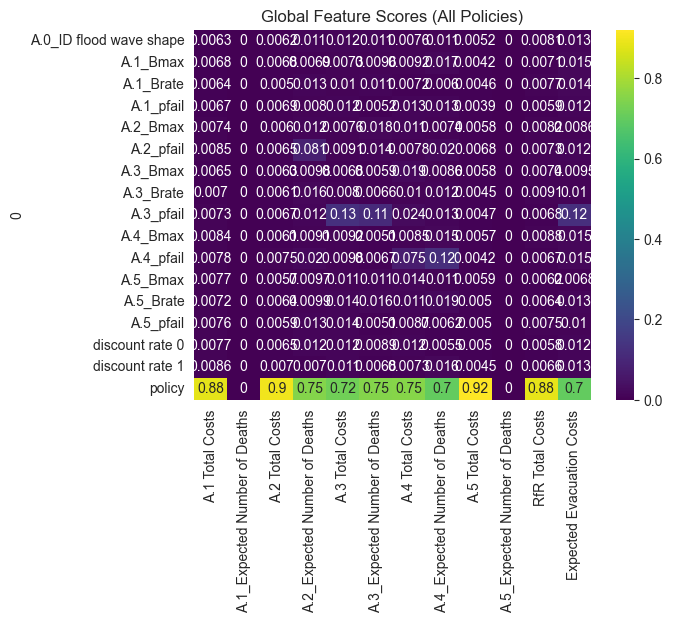

In [8]:
def compute_global_feature_scores(experiments, outcomes, model):
    input_df = experiments.drop(columns=[l.name for l in model.levers])
    return feature_scoring.get_feature_scores_all(input_df, outcomes)

global_scores = compute_global_feature_scores(experiments_sobol, outcomes_sobol, dike_model)

# Optional: Visualize
sns.heatmap(global_scores, annot=True, cmap='viridis')
plt.title("Global Feature Scores (All Policies)")
plt.show()


## 6. Feature Scoring Per Policy
We now isolate experiments by policy and calculate feature scores separately.


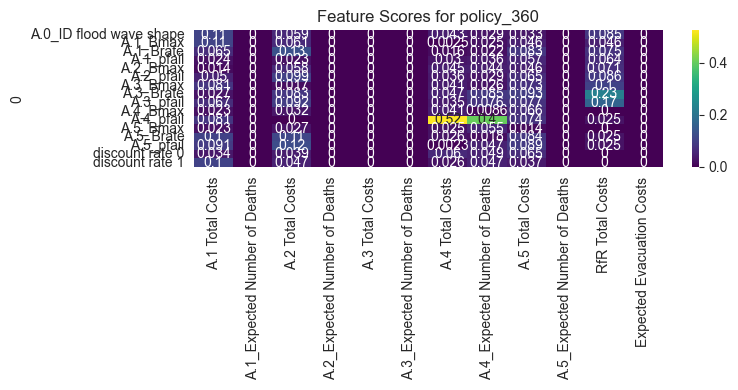

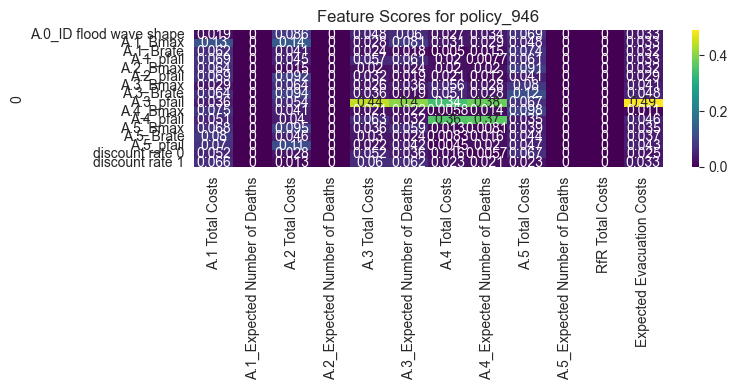

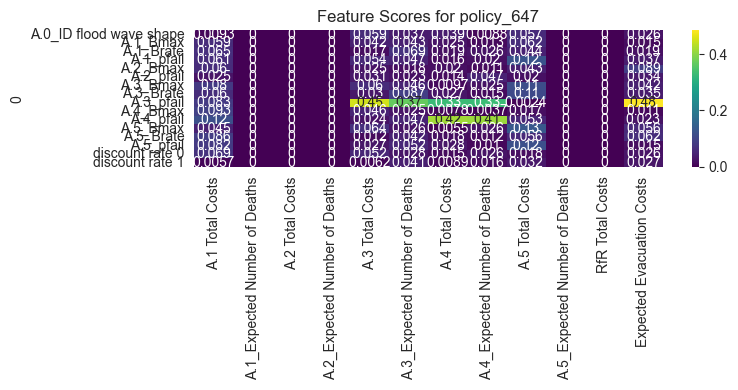

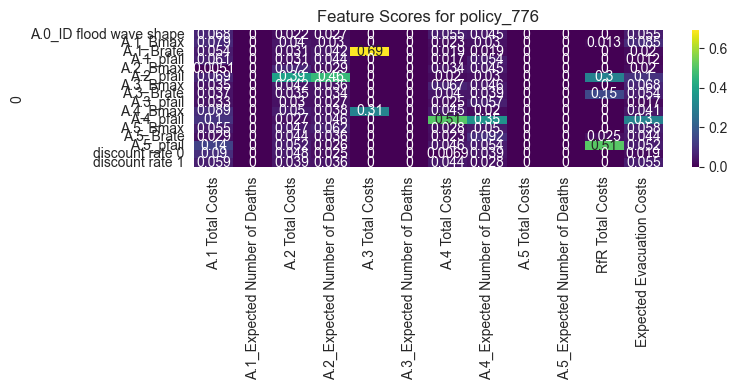

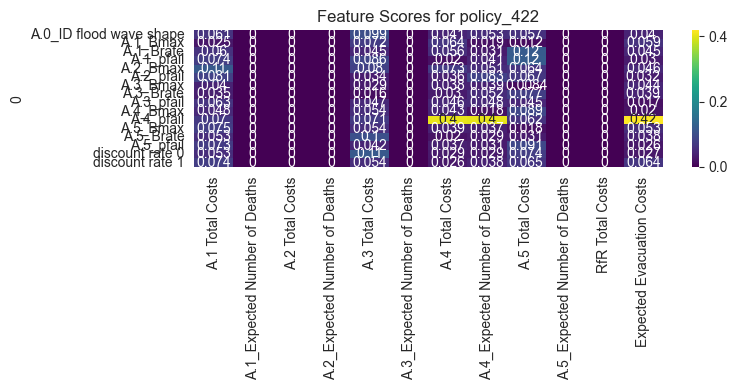

In [9]:
def plot_feature_scores_per_policy(experiments, outcomes, model):
    input_cols = [l.name for l in model.levers]
    cleaned = experiments.drop(columns=input_cols)

    for policy in experiments.policy.unique():
        mask = experiments.policy == policy
        subset_outcomes = {k: v[mask] for k, v in outcomes.items()}
        subset_inputs = cleaned[mask]

        scores = feature_scoring.get_feature_scores_all(subset_inputs, subset_outcomes)
        plt.figure(figsize=(8, 4))
        sns.heatmap(scores, annot=True, cmap='viridis')
        plt.title(f"Feature Scores for {policy}")
        plt.tight_layout()
        plt.show()

plot_feature_scores_per_policy(experiments_sobol, outcomes_sobol, dike_model)


## 7. Optional: Visualize Specific Sobol Result (e.g., from one policy)


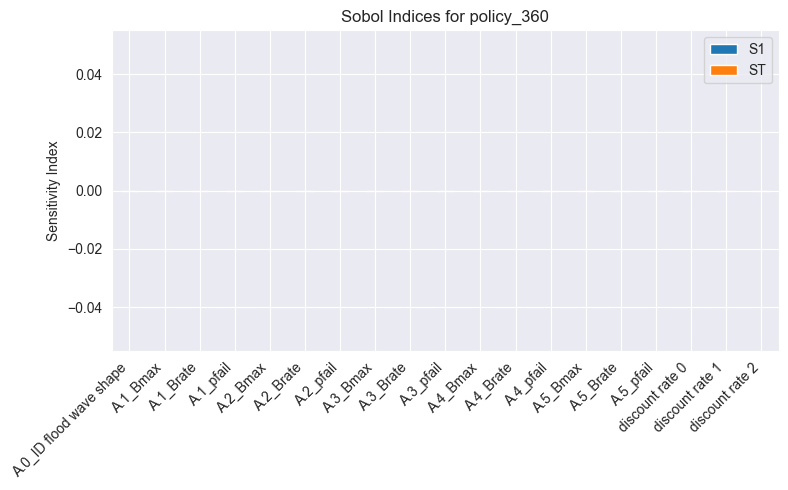

In [10]:
def plot_sobol_indices(indices, policy_name):
    Si_df = pd.DataFrame({
        'S1': indices['S1'],
        'S1_conf': indices['S1_conf'],
        'ST': indices['ST'],
        'ST_conf': indices['ST_conf']
    }, index=problem['names'])

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    Si_df[['S1', 'ST']].plot.bar(yerr=Si_df[['S1_conf', 'ST_conf']].values.T, ax=ax)
    plt.title(f"Sobol Indices for {policy_name}")
    plt.ylabel("Sensitivity Index")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Example: visualize one
plot_sobol_indices(sobol_results['policy_360'], 'policy_360')
